In [1]:
import pandas as pd

## **1.DATA LOADING**

In [2]:
df = pd.read_csv("../data/amazon_sales_report.csv"  , low_memory = False)

In [3]:
df.shape

(128975, 24)

In [4]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## **2.DATA CLEANING**

In [5]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [7]:
df['currency'].value_counts()

currency
INR    121180
Name: count, dtype: int64

In [8]:
df["Style"].value_counts().head()

Style
JNE3797    4224
JNE3405    2263
J0230      1868
SET268     1860
J0341      1630
Name: count, dtype: int64

In [9]:
df['promotion-ids'].value_counts()

promotion-ids
IN Core Free Shipping 2015/04/08 23-48-5-108                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [10]:
df['Status'].value_counts()

Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [11]:
df[df['Amount'].isnull()]['Status'].value_counts()

Status
Cancelled                       7566
Shipped                          208
Shipped - Delivered to Buyer       8
Shipping                           8
Shipped - Returned to Seller       3
Pending                            2
Name: count, dtype: int64

In [12]:
df["fulfilled-by"].value_counts()

fulfilled-by
Easy Ship    39277
Name: count, dtype: int64

In [13]:
df.groupby('Fulfilment')['fulfilled-by'].value_counts(dropna=False)

Fulfilment  fulfilled-by
Amazon      NaN             89698
Merchant    Easy Ship       39277
Name: count, dtype: int64

In [14]:
df[df['ship-city'].isnull()]

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
1871,1871,404-0566904-4825137,04-29-22,Shipped,Amazon,Amazon.in,Expedited,J0301,J0301-TP-L,Top,...,INR,493.0,NaN,NaN,NaN,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
1872,1872,404-0566904-4825137,04-29-22,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-L,kurta,...,INR,458.0,NaN,NaN,NaN,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
8752,8752,406-4003386-8768363,04-25-22,Shipped,Amazon,Amazon.in,Expedited,JNE3376,JNE3376-KR-M,kurta,...,INR,432.0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
11215,11215,402-0107720-7057168,04-23-22,Shipped,Amazon,Amazon.in,Expedited,J0003,J0003-SET-S,Set,...,INR,654.0,NaN,NaN,NaN,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
13252,13252,407-4532637-8415521,04-22-22,Cancelled,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,...,INR,380.0,NaN,NaN,NaN,NaN,NaN,False,Easy Ship,NaN
15688,15688,404-9229894-8608305,04-21-22,Shipped,Amazon,Amazon.in,Expedited,JNE3510,JNE3510-KR-M,kurta,...,INR,442.0,NaN,NaN,NaN,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
16787,16787,402-4919636-4333150,04-20-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE1233,JNE1233-BLUE-KR-031-XXXL,kurta,...,INR,376.0,NaN,NaN,NaN,NaN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
18351,18351,405-4927647-8064368,04-19-22,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-XS,Set,...,INR,1112.0,NaN,NaN,NaN,NaN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
22930,22930,402-8628677-0457954,04-16-22,Shipped - Returned to Seller,Merchant,Amazon.in,Standard,J0003,J0003-SET-S,Set,...,INR,654.0,NaN,NaN,NaN,NaN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
24986,24986,406-4079063-8291520,04-15-22,Cancelled,Amazon,Amazon.in,Expedited,JNE3567,JNE3567-KR-XXL,kurta,...,INR,399.0,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN


### ***Dropping Irrelevant Columns***

#### Dropping 'currency' because it contains only one unique value (INR) and adds no analytical value.
#### Dropping 'SKU' because it is a product identifier and is not required for this business analysis.
#### Dropping 'ship-postal-code' because city and state provide sufficient geographical insights for this project.
#### Dropping 'promotion-ids' because promotion-level analysis is outside the scope of this sales analysis project.
#### Dropping 'Unnamed: 22' because it is an irrelevant/accidental column with no meaningful information.
#### # Dropping 'fulfilled-by' because it is fully redundant with 'Fulfilment' —
- it equals 'Easy Ship' whenever Fulfilment == 'Merchant' and is NaN whenever
- Fulfilment == 'Amazon', so it adds no new information.
#### # Keeping Amount as NaN for rows with no finalized sale (mostly Cancelled orders).
- NaN is safer than filling with 0 because pandas' .sum() and .mean() automatically
- skip NaN values, whereas 0 would wrongly pull down metrics like average order value.

In [15]:
df.drop(columns=['currency', 'SKU', 'ship-postal-code', 'promotion-ids', 'Unnamed: 22', 'fulfilled-by'], inplace=True)

#### Amount: keeping as NaN (mostly Cancelled orders, no finalized sale — 
- NaN is safely skipped by .sum()/.mean(), unlike filling with 0)
- No code needed here — just leaving Amount untouched

#### ship-city, ship-state, ship-country: filling with 'Unknown' to keep rows usable
- for non-geo analysis while making missing geo data explicit/traceable

In [16]:
df['ship-city'] = df['ship-city'].fillna('Unknown')
df['ship-state'] = df['ship-state'].fillna('Unknown')
df['ship-country'] = df['ship-country'].fillna('Unknown')

In [17]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10796\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [18]:
df['Date'].head(10)

0   2022-04-30
1   2022-04-30
2   2022-04-30
3   2022-04-30
4   2022-04-30
5   2022-04-30
6   2022-04-30
7   2022-04-30
8   2022-04-30
9   2022-04-30
Name: Date, dtype: datetime64[us]

In [19]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

In [20]:
df['Date'].dtype
df['Date'].head()

0   2022-04-30
1   2022-04-30
2   2022-04-30
3   2022-04-30
4   2022-04-30
Name: Date, dtype: datetime64[us]

In [21]:
df['Date'].isnull().sum()

np.int64(0)

In [22]:
df[df['Courier Status'].isnull()]['Status'].value_counts()

Status
Cancelled                       6861
Shipped - Delivered to Buyer       8
Shipped - Returned to Seller       3
Name: count, dtype: int64

In [23]:
df.columns.tolist()

['index',
 'Order ID',
 'Date',
 'Status',
 'Fulfilment',
 'Sales Channel ',
 'ship-service-level',
 'Style',
 'Category',
 'Size',
 'ASIN',
 'Courier Status',
 'Qty',
 'Amount',
 'ship-city',
 'ship-state',
 'ship-country',
 'B2B']

#### Filling Courier Status nulls with 'Not Applicable' instead of 'Unknown'.
- ~99.8% of these nulls come from Cancelled orders, where a courier was
never involved in the first place — so the status doesn't just have missing 
data, it structurally doesn't apply. 'Not Applicable' reflects that accurately,
unlike 'Unknown' which would imply the info exists but wasn't recorded.

In [24]:
df['Courier Status'] = df['Courier Status'].fillna('Not Applicable')

In [25]:
df.isnull().sum()

index                    0
Order ID                 0
Date                     0
Status                   0
Fulfilment               0
Sales Channel            0
ship-service-level       0
Style                    0
Category                 0
Size                     0
ASIN                     0
Courier Status           0
Qty                      0
Amount                7795
ship-city                0
ship-state               0
ship-country             0
B2B                      0
dtype: int64

## **3. Exploratory Data Analysis**

### **A) Category Performance — Which product categories generate the highest sales volume and revenue?**

In [26]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-country,B2B
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,Set,S,B09KXVBD7Z,Not Applicable,0,647.62,MUMBAI,MAHARASHTRA,IN,False
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,kurta,3XL,B09K3WFS32,Shipped,1,406.00,BENGALURU,KARNATAKA,IN,False
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,kurta,XL,B07WV4JV4D,Shipped,1,329.00,NAVI MUMBAI,MAHARASHTRA,IN,True
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,Western Dress,L,B099NRCT7B,Not Applicable,0,753.33,PUDUCHERRY,PUDUCHERRY,IN,False
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,Top,3XL,B098714BZP,Shipped,1,574.00,CHENNAI,TAMIL NADU,IN,False


In [27]:
grouped = df.groupby('Category')['Amount'].sum()

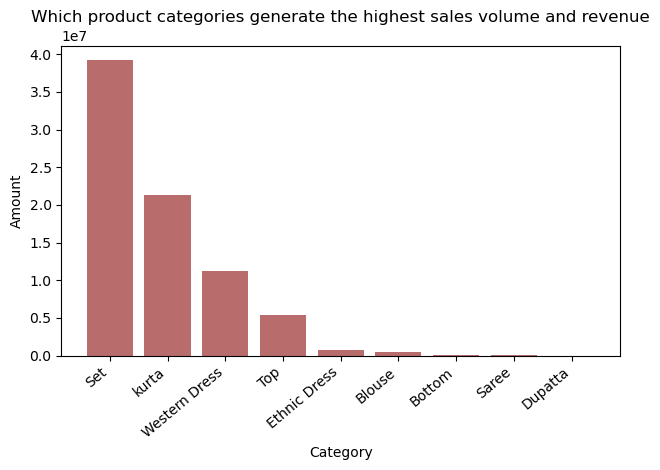

In [28]:
import matplotlib.pyplot as plt
grouped = grouped.sort_values(ascending = False)
plt.bar(grouped.index , grouped.values , color = '#B86C6C')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.title('Which product categories generate the highest sales volume and revenue')
plt.xticks(rotation=40, ha='right')  # rotates labels, ha='right' aligns them neatly under the ticks
plt.tight_layout()  # prevents labels from getting cut off at the edges
plt.show()

#### **Insight:** **"Set"** is by far the highest revenue-generating category, followed by 
 **"Kurta"** and **"Western Dress."** Categories like **"Blouse"**, **"Bottom"** , **"Dupatta"**, and 
**"Saree"** contribute minimally to overall revenue.

### **B) Style Trends — Which product styles are most popular among customers?**

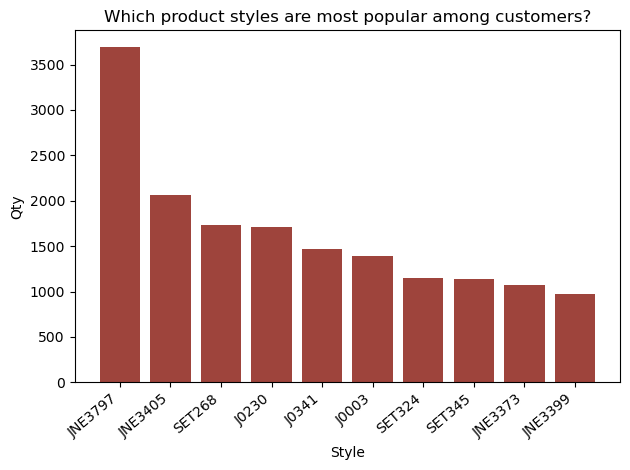

In [29]:
style_qty = df.groupby('Style')['Qty'].sum()
style_qty = style_qty.sort_values(ascending = False)
top_styles = style_qty.head(10)
plt.bar(top_styles.index , top_styles.values , color = '#9E443C')
plt.xlabel('Style')
plt.ylabel('Qty')
plt.title('Which product styles are most popular among customers?')
plt.xticks(rotation=40, ha='right')  
plt.tight_layout()  
plt.show()

In [30]:
top_styles.head(10)

Style
JNE3797    3692
JNE3405    2067
SET268     1731
J0230      1710
J0341      1471
J0003      1390
SET324     1152
SET345     1134
JNE3373    1070
JNE3399     971
Name: Qty, dtype: int64

### **INSIGHT**
- "JNE3797 is the clear best-seller with 3,692 units sold — about 1.8x more than the second-place style (JNE3405, 2,067 units). 
This suggests demand is fairly concentrated at the top rather than spread evenly, meaning inventory/stock priority could reasonably favor this style."

### **C) Regional Delivery Volume: which states/cities get the most deliveries.**

In [38]:
delivery_status = df[df['Status'] == 'Shipped - Delivered to Buyer']
delivery_status

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-country,B2B
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,kurta,3XL,B09K3WFS32,Shipped,1,406.0,BENGALURU,KARNATAKA,IN,False
7,7,406-7807733-3785945,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,kurta,S,B081WX4G4Q,Shipped,1,399.0,HYDERABAD,TELANGANA,IN,False
12,12,405-5513694-8146768,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,kurta,XS,B081XCMYXJ,Shipped,1,399.0,Amravati.,MAHARASHTRA,IN,False
14,14,408-1298370-1920302,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0351,Set,L,B09CSSQY4F,Shipped,1,771.0,MUMBAI,MAHARASHTRA,IN,False
15,15,403-4965581-9520319,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,PJNE3368,kurta,6XL,B09PY99SVJ,Shipped,1,544.0,GUNTAKAL,ANDHRA PRADESH,IN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128872,128872,405-4724097-1016369,2022-06-01,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0243,Ethnic Dress,S,B092648LBY,Shipped,1,999.0,ALLUR,ANDHRA PRADESH,IN,False
128873,128873,405-4724097-1016369,2022-06-01,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0079,Set,S,B08XNG67ZL,Shipped,1,1523.0,ALLUR,ANDHRA PRADESH,IN,False
128874,128874,405-4724097-1016369,2022-06-01,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0009,Set,S,B0894X8979,Shipped,1,854.0,ALLUR,ANDHRA PRADESH,IN,False
128887,128887,405-6493630-8542756,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0301,Top,M,B099S9DTR2,Shipped,1,518.0,NOIDA,UTTAR PRADESH,IN,False


In [43]:
df['ship-state'].unique()

<ArrowStringArray>
[           'MAHARASHTRA',              'KARNATAKA',             'PUDUCHERRY',
             'TAMIL NADU',          'UTTAR PRADESH',             'CHANDIGARH',
              'TELANGANA',         'ANDHRA PRADESH',              'RAJASTHAN',
                  'DELHI',                'HARYANA',                  'ASSAM',
              'JHARKHAND',           'CHHATTISGARH',                 'ODISHA',
                 'KERALA',         'MADHYA PRADESH',            'WEST BENGAL',
               'NAGALAND',                'Gujarat',            'UTTARAKHAND',
                  'BIHAR',        'JAMMU & KASHMIR',                 'PUNJAB',
       'HIMACHAL PRADESH',      'ARUNACHAL PRADESH',                'MANIPUR',
                    'Goa',              'MEGHALAYA',                    'GOA',
                'TRIPURA',                 'LADAKH',        'DADRA AND NAGAR',
                 'SIKKIM',                  'Delhi',                'Unknown',
     'ANDAMAN & NICOBAR ',       

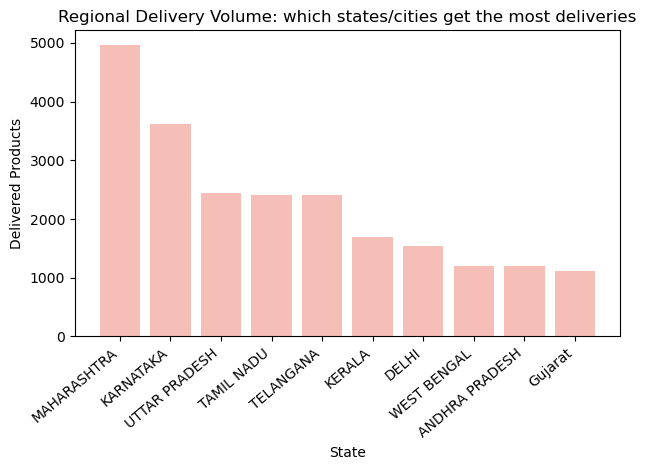

In [42]:
state_deliveries = delivery_status.groupby('ship-state').size()
state_deliveries = state_deliveries.sort_values(ascending=False)
top_states = state_deliveries.head(10)
plt.bar(top_states.index , top_states.values , color = '#F5BFB8')
plt.xlabel('State')
plt.ylabel('Delivered Products')
plt.title('Regional Delivery Volume: which states/cities get the most deliveries')
plt.xticks(rotation = 40 , ha = 'right')
plt.tight_layout()
plt.show()

### **INSIGHT** : 
- Maharashtra has more number of delivereis followed by Karnataka and UP 